### Partial Least Squares Regression with the California Housing Dataset.

Source Data: California Housing Data (1990)
Google Link: https://www.kaggle.com/datasets/harrywang/housing?resource=download


About the Data (from the book):
"This dataset is a modified version of the California Housing dataset available from Luís Torgo's page (University of Porto). Luís Torgo obtained it from the StatLib repository (which is closed now). The dataset may also be downloaded from StatLib mirrors.

The following is the description from the book author:

This dataset appeared in a 1997 paper titled Sparse Spatial Autoregressions by Pace, R. Kelley and Ronald Barry, published in the Statistics and Probability Letters journal. They built it using the 1990 California census data. It contains one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).

#### Data

In [26]:
# Data Extraction.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

base_pth = 'drive/My Drive/Tufts/Masters Thesis Research/Partial_Least_Squares'
df = pd.read_csv(f'{base_pth}/housing.csv')
df_copy = df.copy()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
# Dataset information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [29]:
# Get missing values across
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


##### Plot Numeric Data

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


/tmp/ipython-input-1844132915.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[numeric_column].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-1844132915.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

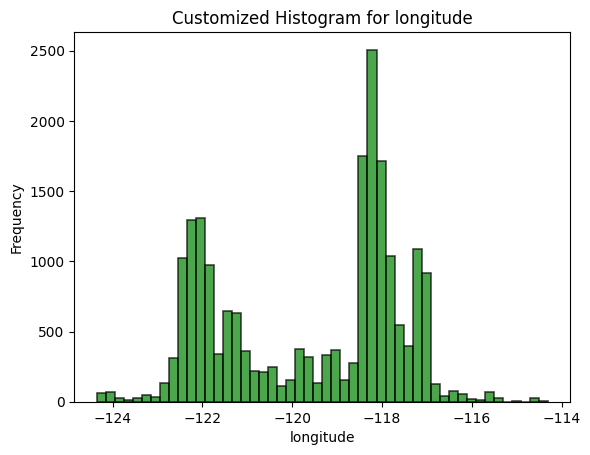

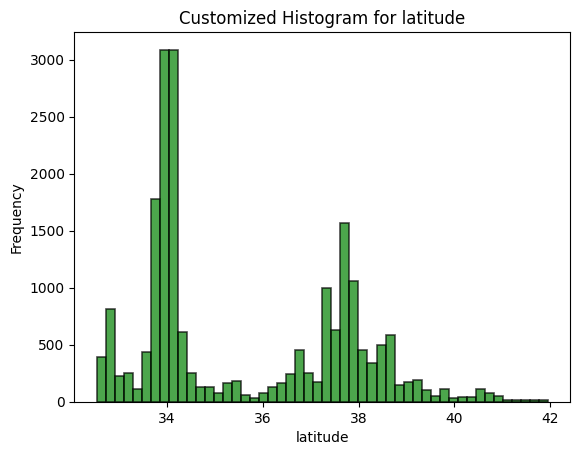

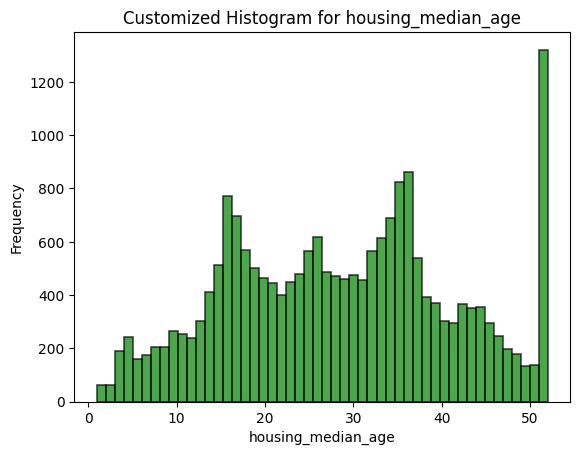

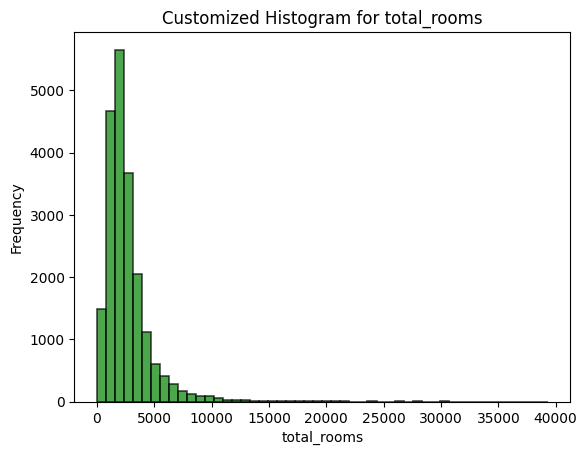

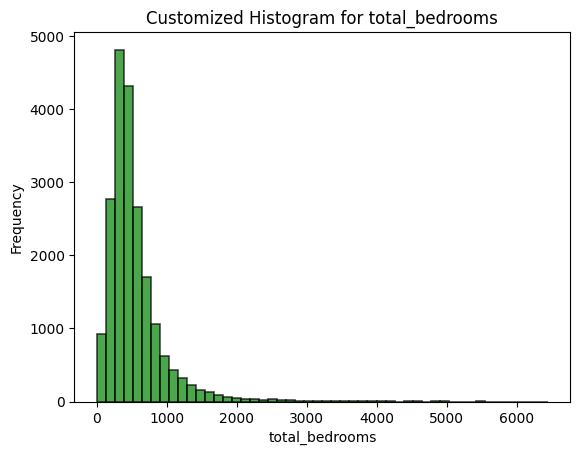

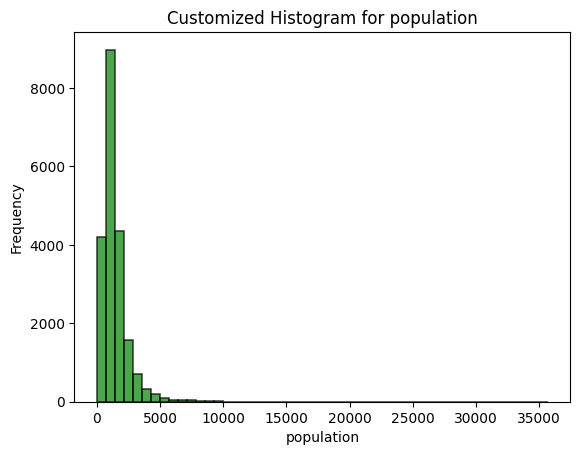

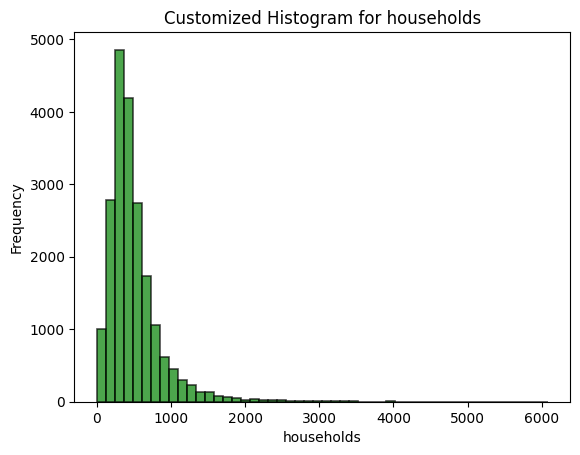

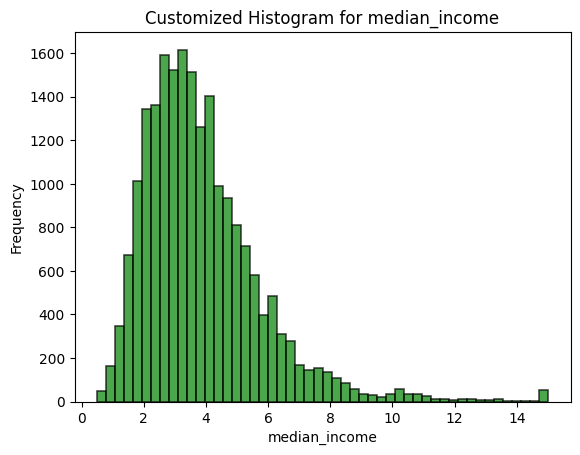

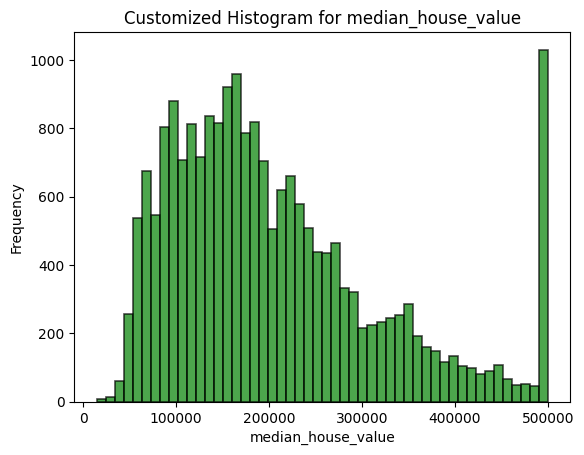

In [30]:
import matplotlib.pyplot as plt
import numpy as np

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_columns)

# Impute The Missing Data - Moved before QuantileTransformer
for numeric_column in numeric_columns:
    if numeric_column == 'id':
        continue
    # Replace infinite values that might result from division by zero
    df[numeric_column].replace([np.inf, -np.inf], np.nan, inplace=True)
    df[numeric_column].fillna(df[numeric_column].median(), inplace=True)

# Create histogram for the numeric columns.
for column in numeric_columns:
  if column == 'id':
    continue

  # Create histogram to obtain normal distribution of the numeric variables.
  plt.figure()
  plt.hist(df[column], bins=50, color='green', alpha=0.7, edgecolor='black', linewidth=1.2)
  plt.title(f'Customized Histogram for {df[column].name}')
  plt.xlabel(f'{df[column].name}') # Removed (Transformed)
  plt.ylabel('Frequency')
  plt.show()

In [31]:
# Impute The Missing Data
for numeric_column in numeric_columns:
  if numeric_column == 'id':
    continue

  df[numeric_column].fillna(df[numeric_column].median(), inplace=True)

df.describe()

/tmp/ipython-input-798098293.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[numeric_column].fillna(df[numeric_column].median(), inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### Plot Categorical Data

In [32]:
from sklearn.impute import SimpleImputer
categorical_columns = df.select_dtypes(include=['object']).columns

# Create histogram for the numeric columns.
for column in categorical_columns:
  if column == 'id':
    continue

  df[column] = SimpleImputer(strategy='most_frequent').fit_transform(df[column].values.reshape(-1, 1))[:, 0]
  print(df[column].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [33]:
# Perform one-hot encoding on columns with 10 or fewer unique values
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], dummy_na=False, dtype=int)

# The top 10 columns have already been created as separate columns with boolean values.
# We can now drop the original 'manufacturer', 'type', 'state', and 'region' columns
df_encoded = df_encoded.drop('ocean_proximity', axis=1, errors='ignore')

# Display the first few rows of the encoded DataFrame and its info to see the changes
display(df_encoded.head())
display(df_encoded.info())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  int64  
 10  ocean_proximity_INLAND      20640 non-null  int64  
 11  ocean_proximity_ISLAND      20640 non-null  int64  
 12  ocean_proximity_NEAR BAY    20640 non-null  int64  
 13  ocean_proximity_NEAR OCEAN  206

None

#### Data Preparation

In [34]:
# Preparing the data, extracting the prices.
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def prepare_data(df, feature_cols, test_size=0.3):
    """
    Prepare data for training

    Args:
        df: DataFrame with features and price
        feature_cols: List of feature column names
        test_size: Fraction for test set
        val_size: Fraction of train for validation

    Returns:
        Dictionary with train/val/test splits and scaler
    """
    # X will contain features specified in feature_cols
    X = df[feature_cols].values
    print(f"[prepare_data] Shape of X (before split): {X.shape}") # Diagnostic print
    print(f"[prepare_data] X features head (first row): {X[0, :5]}...") # Diagnostic print

    y = df['median_house_value'].values

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"X_train min/max BEFORE feature scaling: [{X_train.min():.2f}, {X_train.max():.2f}]")
    # This is more robust to outliers than StandardScaler or MinMaxScaler for non-Gaussian data
    feature_scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
    print(f"Type of feature_scaler: {type(feature_scaler)}")
    X_train_raw = X_train.copy()
    X_train = feature_scaler.fit_transform(X_train)
    X_test = feature_scaler.transform(X_test)
    print(f"X_train min/max AFTER feature scaling: [{X_train.min():.2f}, {X_train.max():.2f}]")

    price_scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
    y_train_scaled = price_scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = price_scaler.transform(y_test.reshape(-1, 1))

    print(f"Train: {len(X_train)} samples")
    print(f"Test: {len(X_test)} samples")
    print(f"Feature dim: {X_train.shape[1]}")

    # Print transformed price range and stats
    print(f"Transformed Price range (log1p): {y_train_scaled.min():.2f} - {y_train_scaled.max():.2f}")
    print(f"Transformed Price mean (log1p): {y_train_scaled.mean():.2f} \u00b1 {y_train_scaled.std():.2f}")

    print(f"\u2713 Features range: [{X_train.min():.2f}, {X_train.max():.2f}]")
    print(f"\u2713 Prices range: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]")

    return {
        'X_train': X_train,
        'X_train_raw': X_train_raw,
        'y_train_raw': y_train,
        'y_train': y_train_scaled,
        'X_test': X_test,
        'y_test': y_test_scaled,
        'feature_scaler': feature_scaler,
        'price_scaler': price_scaler,
        'y_train_raw': y_train,
        'y_test_raw': y_test,
    }

# --- MODIFIED: feature_columns now explicitly EXCLUDES 'median_house_value'
feature_columns = [col for col in df_encoded.select_dtypes(include=['number']).columns if col not in ['median_house_value']]

print(f"Feature columns for KDS model: {feature_columns}")
print(f"Length of feature_columns: {len(feature_columns)}") # Diagnostic print

# Diagnostic: Check df_encoded numeric columns
print("\n--- df Numeric Column Check ---")
print(f"df.shape: {df_encoded.shape}")
numeric_cols_in_df_encoded = df_encoded.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns in df_encoded: {len(numeric_cols_in_df_encoded)}")
print(f"Numeric column names (first 5): {numeric_cols_in_df_encoded[:5]}")
print("---------------------------------------")

data_splits = prepare_data(df_encoded, feature_columns)

# Unpack the dictionary into individual variables
X_train = data_splits['X_train']
X_train_raw = data_splits['X_train_raw']
y_train = data_splits['y_train']
X_test = data_splits['X_test']
y_test = data_splits['y_test']
feature_scaler = data_splits['feature_scaler']
price_scaler = data_splits['price_scaler']
y_train_raw = data_splits['y_train_raw']
y_test_raw = data_splits['y_test_raw']

df_train = pd.DataFrame(X_train, columns=feature_columns)
df_train['median_house_value'] = y_train

df_train_raw = pd.DataFrame(X_train_raw, columns=feature_columns)
df_train_raw['median_house_value'] = y_train_raw

print(df_train_raw)

Feature columns for KDS model: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Length of feature_columns: 13

--- df Numeric Column Check ---
df.shape: (20640, 14)
Numeric columns in df_encoded: 14
Numeric column names (first 5): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms']
---------------------------------------
[prepare_data] Shape of X (before split): (20640, 13)
[prepare_data] X features head (first row): [-122.23   37.88   41.    880.    129.  ]...
X_train min/max BEFORE feature scaling: [-124.35, 35682.00]
Type of feature_scaler: <class 'sklearn.preprocessing._data.QuantileTransformer'>
X_train min/max AFTER feature scaling: [0.00, 1.00]
Train: 14448 samples
Test: 6192 samples
Feature dim: 13
Transformed Price range (log1p): 0.00 -

#### PLS Clustering

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cross_decomposition import PLSRegression
def perform_pls_clustering(X_train, y_train, n_components=3, n_clusters=5):
    """
    Apply PLS then cluster in PLS component space
    """
    print("="*70)
    print("PLS + CLUSTERING PIPELINE")
    print("="*70)

    # Fit PLS
    print(f"\nStep 1: Fitting PLS with {n_components} components...")
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train, y_train)

    # Transform to PLS space
    X_train_pls = pls.transform(X_train)
    print(f"  PLS scores shape: {X_train_pls.shape}")

    # Perform clustering
    print(f"\nStep 2: K-Means clustering with {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_train_pls)

    # Compute clustering metrics
    sil_score = silhouette_score(X_train_pls, cluster_labels)
    db_score = davies_bouldin_score(X_train_pls, cluster_labels)

    print(f"\nClustering Quality Metrics:")
    print(f"  Silhouette Score: {sil_score:.4f} (higher is better, range [-1, 1])")
    print(f"  Davies-Bouldin Score: {db_score:.4f} (lower is better)")

    return pls, kmeans, X_train_pls, cluster_labels

In [36]:
def plot_elbow_method(X_train_pls, k_range=range(2, 16)):
    """
    Determine optimal number of clusters (like your KDS Figure 7.3.1.1)
    """
    inertias = []
    silhouette_scores = []

    print("\nComputing elbow curve...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_train_pls)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_train_pls, labels))

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(k_range, inertias, marker='o', color='black', linewidth=2)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Within-Cluster Sum of Squares', fontsize=12)
    ax1.set_title('Elbow Method: PLS Space', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(k_range, silhouette_scores, marker='s', color='darkblue', linewidth=2)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title('Silhouette Score vs. K', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{base_pth}/KMeans_Figures/pls_elbow_method.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: pls_elbow_method.png")
    plt.show()

In [37]:
# ============================================================================
# SECTION 4: CLUSTER VISUALIZATION (Multi-panel like your Figure 7.3.5.3)
# ============================================================================

def visualize_clusters(X_train_pls, cluster_labels, df_train, y_train):
    """
    Comprehensive cluster visualization across 6 panels
    """
    print("\n" + "="*70)
    print("CREATING CLUSTER VISUALIZATIONS")
    print("="*70)

    n_clusters = len(np.unique(cluster_labels))
    df_plot = df_train.copy()
    df_plot['cluster'] = cluster_labels
    df_plot['median_house_value'] = price_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    # ========================================================================
    # Panel 1: PLS Component Space (Main clustering view)
    # ========================================================================
    for i in range(n_clusters):
        mask = cluster_labels == i
        axes[0, 0].scatter(X_train_pls[mask, 0], X_train_pls[mask, 1],
                          c=[colors[i]], label=f'Cluster {i}',
                          alpha=0.6, s=20, edgecolors='black', linewidth=0.3)

    axes[0, 0].set_xlabel('PLS Component 1', fontsize=11)
    axes[0, 0].set_ylabel('PLS Component 2', fontsize=11)
    axes[0, 0].set_title('Clusters in PLS Space', fontsize=13, fontweight='bold')
    axes[0, 0].legend(loc='best')
    axes[0, 0].grid(True, alpha=0.3)

    # ========================================================================
    # Panel 2: Price Distribution by Cluster
    # ========================================================================
    for i in range(n_clusters):
        cluster_prices = df_plot[df_plot['cluster'] == i]['median_house_value']
        axes[0, 1].hist(cluster_prices, bins=40, alpha=0.6,
                       label=f'Cluster {i}', color=colors[i],
                       edgecolor='black', linewidth=0.5)

    axes[0, 1].set_xlabel('Median House Value ($)', fontsize=11)
    axes[0, 1].set_ylabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Price Distribution by Cluster', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].set_xlim(0, 500000)

    # ========================================================================
    # Panel 3: Cluster Sizes
    # ========================================================================
    cluster_sizes = [np.sum(cluster_labels == i) for i in range(n_clusters)]
    cluster_pcts = [size/len(cluster_labels)*100 for size in cluster_sizes]

    bars = axes[0, 2].bar(range(n_clusters), cluster_sizes, color=colors,
                          edgecolor='black', linewidth=1.5)
    axes[0, 2].set_xlabel('Cluster', fontsize=11)
    axes[0, 2].set_ylabel('Number of Houses', fontsize=11)
    axes[0, 2].set_title('Cluster Sizes', fontsize=13, fontweight='bold')
    axes[0, 2].set_xticks(range(n_clusters))

    # Add percentage labels on bars
    for i, (bar, pct) in enumerate(zip(bars, cluster_pcts)):
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                       f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # ========================================================================
    # Panel 4: Housing Age Distribution
    # ========================================================================
    if 'housing_median_age' in df_train.columns:
        age_data = [df_plot[df_plot['cluster'] == i]['housing_median_age'].values
                    for i in range(n_clusters)]
        bp = axes[1, 0].boxplot(age_data, patch_artist=True,
                                labels=[f'C{i}' for i in range(n_clusters)])

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[1, 0].set_xlabel('Cluster', fontsize=11)
        axes[1, 0].set_ylabel('Housing Median Age (years)', fontsize=11)
        axes[1, 0].set_title('Age Distribution by Cluster', fontsize=13, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

    # ========================================================================
    # Panel 5: Geographic Distribution
    # ========================================================================
    if 'longitude' in df_train.columns and 'latitude' in df_train.columns:
        for i in range(n_clusters):
            mask = df_plot['cluster'] == i
            axes[1, 1].scatter(df_plot.loc[mask, 'longitude'],
                             df_plot.loc[mask, 'latitude'],
                             c=[colors[i]], label=f'Cluster {i}',
                             alpha=0.5, s=8, edgecolors='none')

        axes[1, 1].set_xlabel('Longitude', fontsize=11)
        axes[1, 1].set_ylabel('Latitude', fontsize=11)
        axes[1, 1].set_title('Geographic Distribution', fontsize=13, fontweight='bold')
        axes[1, 1].legend(markerscale=2, loc='best')

    # ========================================================================
    # Panel 6: Price vs Income by Cluster
    # ========================================================================
    if 'median_income' in df_train.columns:
        for i in range(n_clusters):
            mask = df_plot['cluster'] == i
            axes[1, 2].scatter(df_plot.loc[mask, 'median_income'],
                             df_plot.loc[mask, 'median_house_value'],
                             c=[colors[i]], label=f'Cluster {i}',
                             alpha=0.5, s=15, edgecolors='black', linewidth=0.2)

        axes[1, 2].set_xlabel('Median Income (tens of thousands)', fontsize=11)
        axes[1, 2].set_ylabel('Median House Value ($)', fontsize=11)
        axes[1, 2].set_title('Price vs. Income by Cluster', fontsize=13, fontweight='bold')
        axes[1, 2].legend(markerscale=1.5)
        axes[1, 2].set_ylim(0, 500000)

    plt.tight_layout()
    plt.savefig(f'{base_pth}/Clustering/pls_cluster_analysis.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: pls_cluster_analysis.png")
    plt.show()

In [38]:
# ============================================================================
# SECTION 5: DOMINANT FEATURES ANALYSIS
# ============================================================================

def analyze_dominant_features(df_train, df_train_raw, cluster_labels, feature_names, price_scaler, feature_scaler, top_n=8):
    """
    Identify dominant features in each cluster (like your Table/Summary)
    """
    print("\n" + "="*70)
    print("DOMINANT FEATURES BY CLUSTER")
    print("="*70)

    df_analysis = df_train.copy()
    df_analysis['cluster'] = cluster_labels

    # Overall statistics
    overall_means = df_analysis[feature_names].mean()

    for cluster_id in sorted(df_analysis['cluster'].unique()):
        cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
        cluster_size = len(cluster_data)
        cluster_pct = cluster_size / len(df_analysis) * 100

        print(f"\n{'─'*70}")
        print(f"CLUSTER {cluster_id} | Size: {cluster_size:,} ({cluster_pct:.1f}%)")
        print(f"{'─'*70}")

        # Basic statistics
        if 'median_house_value' in df_train.columns:
            avg_price = df_train_raw.loc[cluster_data.index, 'median_house_value'].mean()
            print(f"  Average Price: ${avg_price:,.0f}")

        if 'median_income' in df_train.columns:
            avg_income = df_train_raw.loc[cluster_data.index, 'median_income'].mean()
            print(f"  Average Income: ${avg_income * 10000:,.0f}")

        if 'housing_median_age' in df_train.columns:
            avg_age = df_train_raw.loc[cluster_data.index, 'housing_median_age'].mean()
            print(f"  Average Age: {avg_age:.1f} years")

        # Feature deviations from overall mean
        cluster_means = cluster_data[feature_names].mean()
        deviations = ((cluster_means - overall_means) / (overall_means + 1e-10)) * 100

        # Top features higher than average
        top_higher = deviations.nlargest(top_n)
        print(f"\n  Top {top_n} Features ABOVE Average:")
        for feat, dev in top_higher.items():
            if dev > 5:  # Only show significant deviations
                print(f"    • {feat}: +{dev:.1f}% (cluster mean: {cluster_means[feat]:.3f})")

        # Top features lower than average
        top_lower = deviations.nsmallest(top_n)
        print(f"\n  Top {top_n} Features BELOW Average:")
        for feat, dev in top_lower.items():
            if dev < -5:
                print(f"    • {feat}: {dev:.1f}% (cluster mean: {cluster_means[feat]:.3f})")

# ============================================================================
# SECTION 6: PLS LOADINGS INTERPRETATION
# ============================================================================

def visualize_pls_loadings(pls_model, feature_names, n_components=5):
    """
    Show which original features contribute to each PLS component
    """
    print("\n" + "="*70)
    print("PLS COMPONENT LOADINGS (Feature Importance)")
    print("="*70)

    # Get loadings (x_loadings_ shows feature contributions)
    loadings = pls_model.x_loadings_[:, :n_components]

    fig, axes = plt.subplots(1, n_components, figsize=(20, 6))

    for comp in range(n_components):
        # Get top features for this component
        comp_loadings = loadings[:, comp]
        indices = np.argsort(np.abs(comp_loadings))[-15:]  # Top 15

        values = comp_loadings[indices]
        names = [feature_names[i] for i in indices]

        colors_bar = ['green' if v > 0 else 'red' for v in values]

        axes[comp].barh(range(len(values)), values, color=colors_bar, alpha=0.7, edgecolor='black')
        axes[comp].set_yticks(range(len(values)))
        axes[comp].set_yticklabels(names, fontsize=8)
        axes[comp].set_xlabel('Loading', fontsize=10)
        axes[comp].set_title(f'PLS Component {comp + 1}', fontsize=11, fontweight='bold')
        axes[comp].axvline(0, color='black', linewidth=0.8)
        axes[comp].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'{base_pth}/Clustering/pls_loadings.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: pls_loadings.png")
    plt.show()

#### Results

In [39]:
def adjusted_r_squared(r_squared, n, p):
  second_term = (1 - r_squared) * (n - 1) / (n-p-1)
  final_result = 1 - second_term
  return final_result


Computing elbow curve...
✓ Saved: pls_elbow_method.png


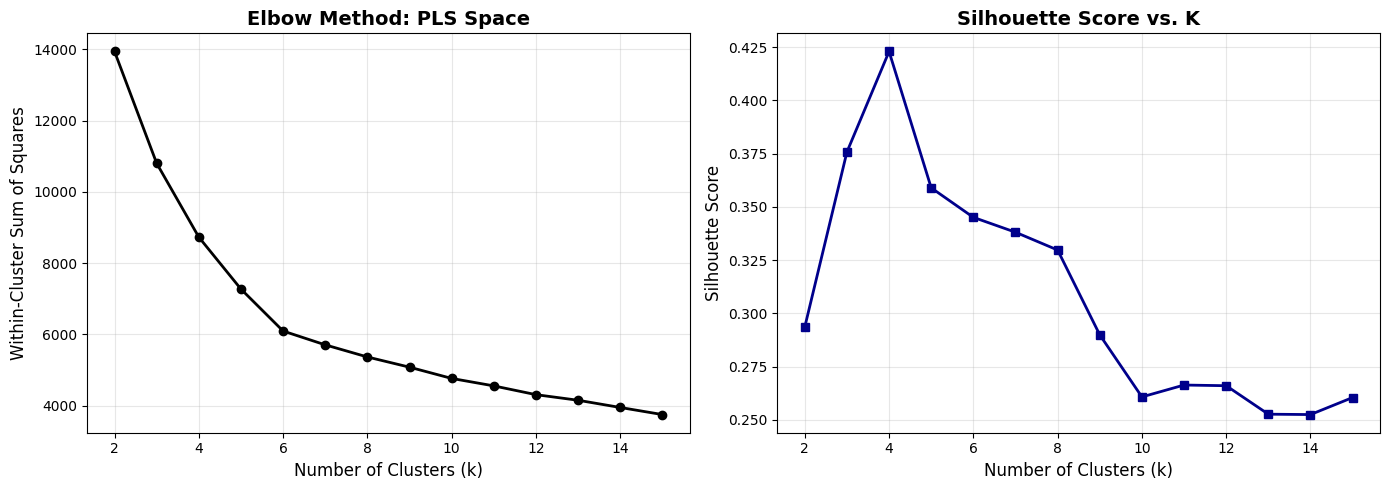

In [40]:
# 1. Determine optimal number of clusters
plot_elbow_method(X_train, k_range=range(2, 16))

In [41]:
# 2. Perform PLS + Clustering
pls_model, kmeans_model, X_train_pls, cluster_labels = perform_pls_clustering(
    X_train, y_train, n_components=2, n_clusters=6
)

PLS + CLUSTERING PIPELINE

Step 1: Fitting PLS with 2 components...
  PLS scores shape: (14448, 2)

Step 2: K-Means clustering with 6 clusters...

Clustering Quality Metrics:
  Silhouette Score: 0.3662 (higher is better, range [-1, 1])
  Davies-Bouldin Score: 0.8180 (lower is better)



CREATING CLUSTER VISUALIZATIONS


/tmp/ipython-input-3652109242.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(age_data, patch_artist=True,


✓ Saved: pls_cluster_analysis.png


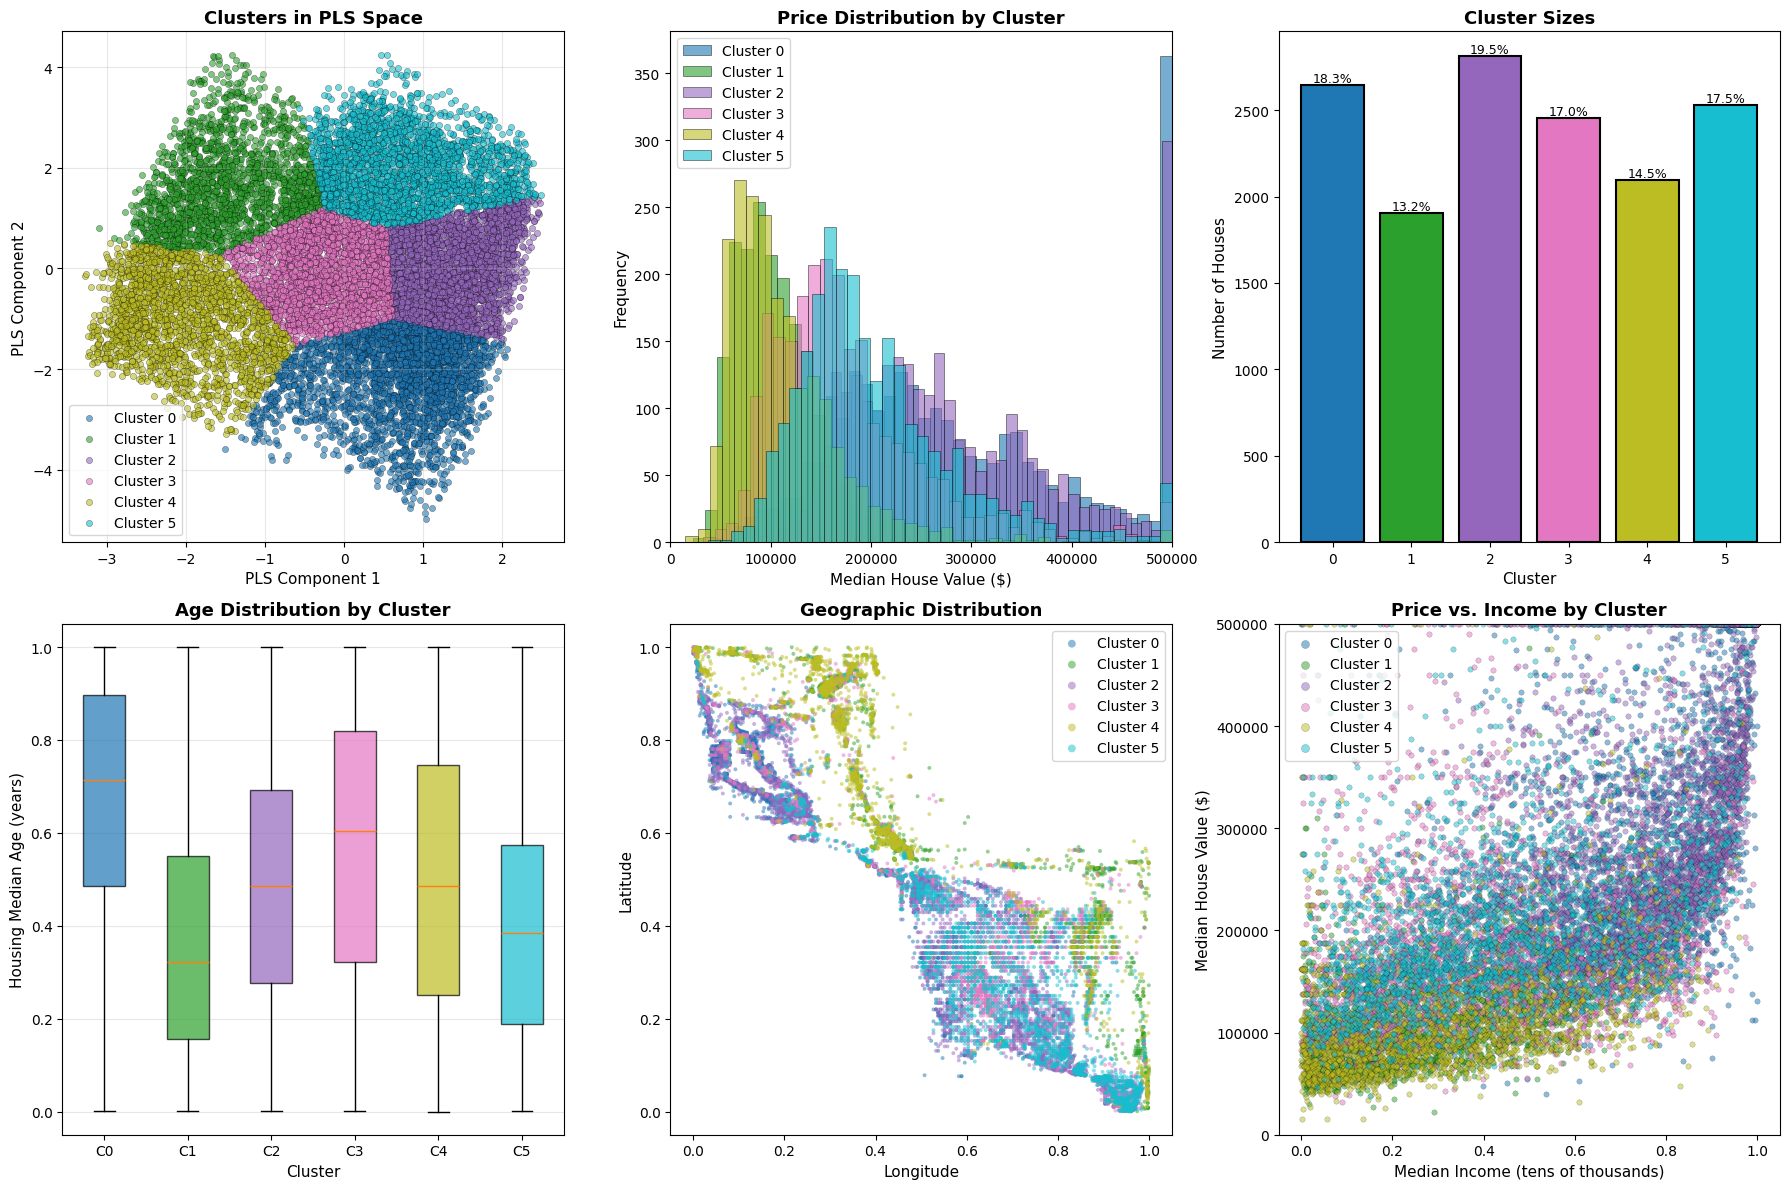


DOMINANT FEATURES BY CLUSTER

──────────────────────────────────────────────────────────────────────
CLUSTER 0 | Size: 2,646 (18.3%)
──────────────────────────────────────────────────────────────────────
  Average Price: $290,789
  Average Income: $52,683
  Average Age: 35.8 years

  Top 8 Features ABOVE Average:
    • ocean_proximity_ISLAND: +446.0% (cluster mean: 0.002)
    • ocean_proximity_NEAR BAY: +201.5% (cluster mean: 0.338)
    • ocean_proximity_NEAR OCEAN: +60.7% (cluster mean: 0.200)
    • median_income: +43.5% (cluster mean: 0.715)
    • housing_median_age: +32.8% (cluster mean: 0.668)
    • latitude: +18.6% (cluster mean: 0.590)

  Top 8 Features BELOW Average:
    • ocean_proximity_INLAND: -86.7% (cluster mean: 0.042)
    • population: -55.1% (cluster mean: 0.225)
    • total_bedrooms: -52.9% (cluster mean: 0.235)
    • households: -51.0% (cluster mean: 0.245)
    • total_rooms: -40.8% (cluster mean: 0.296)
    • longitude: -36.3% (cluster mean: 0.319)
    • ocean_proxim

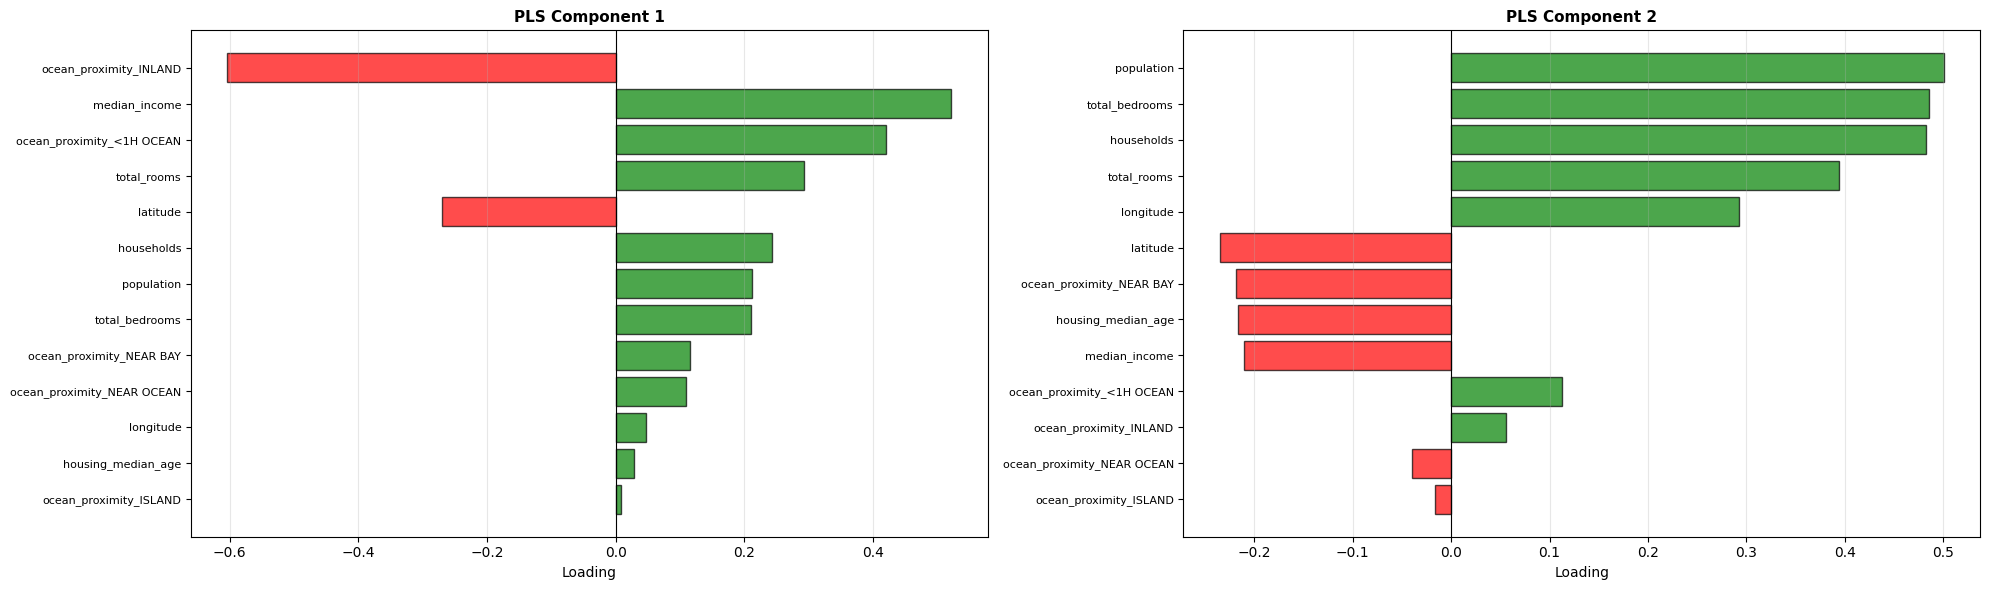

In [42]:
# 3. Visualize clusters
visualize_clusters(X_train_pls, cluster_labels, df_train, y_train)

# 4. Analyze dominant features
analyze_dominant_features(df_train, df_train_raw, cluster_labels, feature_columns, price_scaler=price_scaler, feature_scaler=feature_scaler, top_n=8)

# 5. Interpret PLS components
visualize_pls_loadings(pls_model, feature_columns, n_components=2)


In [45]:
df_analysis = df_train.copy()
df_analysis['cluster'] = cluster_labels

# Overall statistics
overall_means = df_analysis[feature_columns].mean()

for cluster_id in sorted(df_analysis['cluster'].unique()):
  print(f"Cluster ID: {cluster_id}")
  cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
  avg_price = df_train_raw.loc[cluster_data.index, 'median_house_value'].mean()
  print(f"  Average Price: ${avg_price:,.0f}")
  avg_income = df_train_raw.loc[cluster_data.index, 'median_income'].mean()
  print(f"  Average Income: ${avg_income * 10000:,.0f}")


Cluster ID: 0
  Average Price: $290,789
  Average Income: $52,683
Cluster ID: 1
  Average Price: $106,986
  Average Income: $25,582
Cluster ID: 2
  Average Price: $291,595
  Average Income: $53,048
Cluster ID: 3
  Average Price: $177,801
  Average Income: $31,778
Cluster ID: 4
  Average Price: $113,471
  Average Income: $27,704
Cluster ID: 5
  Average Price: $206,020
  Average Income: $34,217
